<a href="https://colab.research.google.com/github/clobos/Biologia_2026/blob/main/semana04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# Correlação Linear de Pearson e Regressão Linear Simples

**Conjunto de dados:** Palmer Penguins  
**Exemplo biológico:** relação entre **comprimento da nadadeira (mm)** e **massa corporal (g)**.

## Objetivos
Ao final deste notebook, você deverá conseguir:

1. construir e interpretar um gráfico de dispersão;
2. calcular e interpretar a correlação linear de Pearson;
3. ajustar uma regressão linear simples;
4. interpretar intercepto, coeficiente angular e $R^2$;
5. visualizar e interpretar resíduos;
6. realizar uma previsão simples;
7. comunicar os resultados em linguagem científica.

> Execute as células na ordem apresentada.



# Correlação Linear de Pearson

O coeficiente de correlação linear de Pearson mede a **direção** e a **intensidade da associação linear** entre duas variáveis quantitativas.

$
r =
\frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}
{\sqrt{
\sum_{i=1}^{n}(x_i-\bar{x})^2
\sum_{i=1}^{n}(y_i-\bar{y})^2
}}
$

com $-1 \leq r \leq 1$

## Interpretação geral

- $r>0$: associação linear positiva;
- $r<0$: associação linear negativa;
- $r\approx 0$: pouca ou nenhuma associação **linear**;
- $|r|$ próximo de 1: associação linear mais forte.

**Importante:** correlação não implica causalidade.



# Regressão Linear Simples

O modelo populacional é:

$
Y_i = \beta_0 + \beta_1X_i + \varepsilon_i
$

em que:

- $Y_i$ variável resposta e $X_i$ variável explicativa
- $\beta_0$ intercepto e $\beta_1$ coeficiente angular
- $\varepsilon_i$ erro aleatório.

A reta estimada a partir da amostra é:

$
\hat{Y}_i=\hat{\beta}_0+\hat{\beta}_1 X_i
$

O coeficiente angular é estimado por:

$
\hat{\beta}_1 =
\frac{\sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y})}
{\sum_{i=1}^{n}(x_i-\bar{x})^2}
$

e o intercepto por:

$
\hat{\beta}_0=\bar{y}-\hat{\beta}_1\bar{x}
$

## Interpretação de $\hat{\beta}_1$

$\hat{\beta}_1$ representa a variação média esperada em $Y$ para um aumento de **uma unidade em $X$**.



## Mínimos quadrados e resíduos

A regressão escolhe a reta que minimiza a soma dos quadrados dos resíduos:

$
\sum_{i=1}^{n}(y_i-\hat{y}_i)^2
$

O resíduo da observação $i$ é:

$
e_i=y_i-\hat{y}_i
$

- resíduo positivo: valor observado acima do previsto;
- resíduo negativo: valor observado abaixo do previsto.

O coeficiente de determinação pode ser escrito como:

$
R^2 = 1-\frac{\sum_{i=1}^{n}(y_i-\hat{y}_i)^2}
{\sum_{i=1}^{n}(y_i-\bar{y})^2}
$

Na regressão linear simples com intercepto:

$
R^2=r^2
$



# 3. Importação das bibliotecas


In [ ]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import pearsonr
import statsmodels.api as sm

pd.set_option("display.max_columns", None)
pd.set_option("display.precision", 3)



# 4. Carregamento dos dados

O notebook tenta carregar diretamente a base pública **Palmer Penguins**.  
Caso a conexão não esteja disponível, será solicitado o envio manual do arquivo CSV.


In [ ]:

url = "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/main/inst/extdata/penguins.csv"

try:
    df = pd.read_csv(url)
    print("Dados carregados diretamente da internet.")
except Exception:
    print("Não foi possível carregar pela URL. Faça o upload do arquivo penguins.csv.")
    from google.colab import files
    uploaded = files.upload()
    nome_arquivo = next(iter(uploaded))
    df = pd.read_csv(nome_arquivo)

print(f"Dimensão da base: {df.shape[0]} linhas × {df.shape[1]} colunas")
df.head()


Dados carregados diretamente da internet.
Dimensão da base: 344 linhas × 8 colunas


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007



# 5. Conhecendo as variáveis

Para esta aula:

- **X = `flipper_length_mm`**: comprimento da nadadeira, em milímetros;
- **Y = `body_mass_g`**: massa corporal, em gramas.

Pergunta biológica:

> Existe associação linear entre o comprimento da nadadeira e a massa corporal dos pinguins?


In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   species            344 non-null    object 
 1   island             344 non-null    object 
 2   bill_length_mm     342 non-null    float64
 3   bill_depth_mm      342 non-null    float64
 4   flipper_length_mm  342 non-null    float64
 5   body_mass_g        342 non-null    float64
 6   sex                333 non-null    object 
 7   year               344 non-null    int64  
dtypes: float64(4), int64(1), object(3)
memory usage: 21.6+ KB


In [ ]:

dados = (
    df[["species", "flipper_length_mm", "body_mass_g"]]
    .dropna()
    .copy()
)

print(f"Número de observações completas: {len(dados)}")
dados.head()


Número de observações completas: 342


,species,flipper_length_mm,body_mass_g
0,Adelie,181.0,3750.0
1,Adelie,186.0,3800.0
2,Adelie,195.0,3250.0
4,Adelie,193.0,3450.0
5,Adelie,190.0,3650.0



# 6. Estatística descritiva


In [ ]:

dados[["flipper_length_mm", "body_mass_g"]].describe()


,flipper_length_mm,body_mass_g
count,342.000,342.000
mean,200.915,4201.754
std,14.062,801.955
min,172.000,2700.000
25%,190.000,3550.000
50%,197.000,4050.000
75%,213.000,4750.000
max,231.000,6300.000



# 7. Gráfico de dispersão

Antes de calcular $r$, devemos observar o padrão dos dados.

Procure responder:

1. a relação parece aproximadamente linear?
2. a direção é positiva ou negativa?
3. existem valores extremos?
4. há agrupamentos?


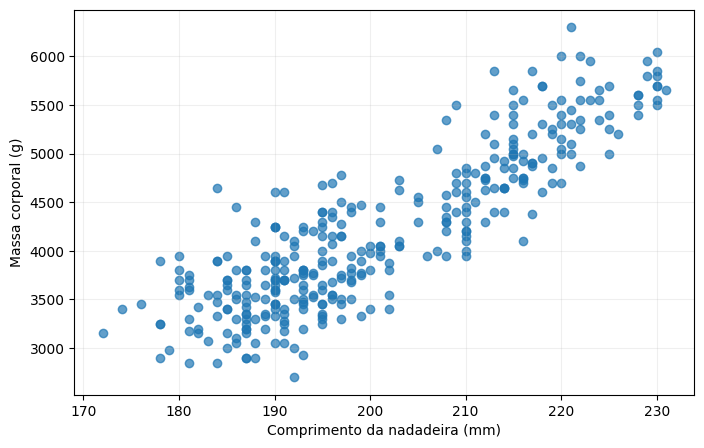

In [ ]:

x = dados["flipper_length_mm"]
y = dados["body_mass_g"]

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.7)
plt.xlabel("Comprimento da nadadeira (mm)")
plt.ylabel("Massa corporal (g)")
plt.grid(alpha=0.2)
plt.show()



# 8. Correlação Linear de Pearson


In [ ]:
r_result = pearsonr(x, y)
r = r_result.statistic
print(f"Correlação de Pearson (r): {r:.3f}")


Correlação de Pearson (r): 0.871



### Resultado esperado

Com as observações completas da base:

$
r \approx 0{,}871
$

Isso indica uma **associação linear positiva forte** entre comprimento da nadadeira e massa corporal.



# 9. Ajuste da Regressão Linear Simples

Modelo:

$
\text{massa corporal} = \beta_0 + \beta_1(\text{comprimento da nadadeira}) + \varepsilon
$


In [ ]:

X = sm.add_constant(x)

modelo = sm.OLS(y, X).fit()

modelo.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            body_mass_g   R-squared:                       0.759
Model:                            OLS   Adj. R-squared:                  0.758
Method:                 Least Squares   F-statistic:                     1071.
Date:                Tue, 25 Aug 2026   Prob (F-statistic):          4.37e-107
Time:                        18:38:09   Log-Likelihood:                -2528.4
No. Observations:                 342   AIC:                             5061.
Df Residuals:                     340   BIC:                             5069.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=====================================================================================
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
const             -5780.8314    305.815    -18.903      0.000   -6382.358   -5179.305
flipper_length_mm    49.6856      1.518     32.722      0.000      46.699      52.672
==============================================================================
Omnibus:                        5.634   Durbin-Watson:                   2.190
Prob(Omnibus):                  0.060   Jarque-Bera (JB):                5.585
Skew:                           0.313   Prob(JB):                       0.0613
Kurtosis:                       3.019   Cond. No.                     2.89e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.89e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""


# 10. Extraindo os principais resultados


In [ ]:

b0 = modelo.params["const"]
b1 = modelo.params["flipper_length_mm"]
r2 = modelo.rsquared

print(f"Intercepto (b0): {b0:.3f}")
print(f"Coeficiente angular (b1): {b1:.3f}")
print(f"R²: {r2:.3f}")


Intercepto (b0): -5780.831
Coeficiente angular (b1): 49.686
R²: 0.759



### Equação estimada

O resultado esperado é aproximadamente:

$
\widehat{\text{massa corporal}}
=
-5780{,}83
+
49{,}69
\times
\text{comprimento da nadadeira}
$

### Interpretação do coeficiente angular

$
b_1 \approx 49{,}69
$

Dentro do intervalo observado, **cada aumento de 1 mm no comprimento da nadadeira está associado a um aumento médio esperado de aproximadamente 49,7 g na massa corporal**.

### Interpretação de $R^2$

$
R^2 \approx 0{,}759
$

Aproximadamente **75,9% da variabilidade observada na massa corporal** é explicada pela relação linear com o comprimento da nadadeira neste modelo simples.

Isso não significa que o comprimento da nadadeira seja a causa de 75,9% da massa corporal.



# 11. Verificando numericamente que $R^2=r^2$


In [ ]:

print(f"r² = {r**2:.6f}")
print(f"R² = {modelo.rsquared:.6f}")
print(f"Diferença = {abs(r**2 - modelo.rsquared):.10f}")


r² = 0.758993
R² = 0.758993
Diferença = 0.0000000000



# 12. Gráfico da reta de regressão

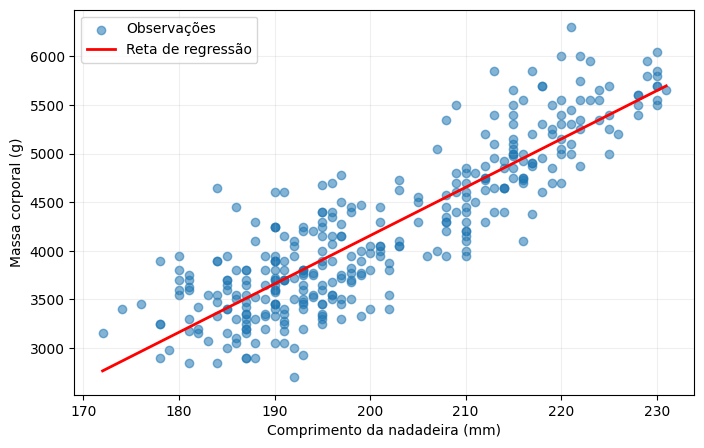

In [ ]:

x_grade = np.linspace(x.min(), x.max(), 200)

X_grade = sm.add_constant(
    pd.DataFrame({"flipper_length_mm": x_grade}),
    has_constant="add"
)

pred_grade = modelo.get_prediction(X_grade).summary_frame(alpha=0.05)

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.55, label="Observações")
plt.plot(
    x_grade,
    pred_grade["mean"],
    linewidth=2,
    color = "red",
    label="Reta de regressão"
)

plt.xlabel("Comprimento da nadadeira (mm)")
plt.ylabel("Massa corporal (g)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()



# 13. Valores ajustados e resíduos

Para cada observação:

$
e_i=y_i-\hat{y}_i
$


In [ ]:

dados["massa_ajustada_g"] = modelo.fittedvalues
dados["residuo_g"] = modelo.resid

dados.head(10)


,species,flipper_length_mm,body_mass_g,massa_ajustada_g,residuo_g
0,Adelie,181.0,3750.0,3212.256,537.744
1,Adelie,186.0,3800.0,3460.684,339.316
2,Adelie,195.0,3250.0,3907.854,-657.854
4,Adelie,193.0,3450.0,3808.483,-358.483
5,Adelie,190.0,3650.0,3659.426,-9.426
6,Adelie,181.0,3625.0,3212.256,412.744
7,Adelie,195.0,4675.0,3907.854,767.146
8,Adelie,193.0,3475.0,3808.483,-333.483
9,Adelie,190.0,4250.0,3659.426,590.574
10,Adelie,186.0,3300.0,3460.684,-160.684



# 14. Diagnóstico: resíduos × valores ajustados

Em uma situação ideal, esperamos uma nuvem aproximadamente aleatória ao redor de zero, sem padrão sistemático evidente.


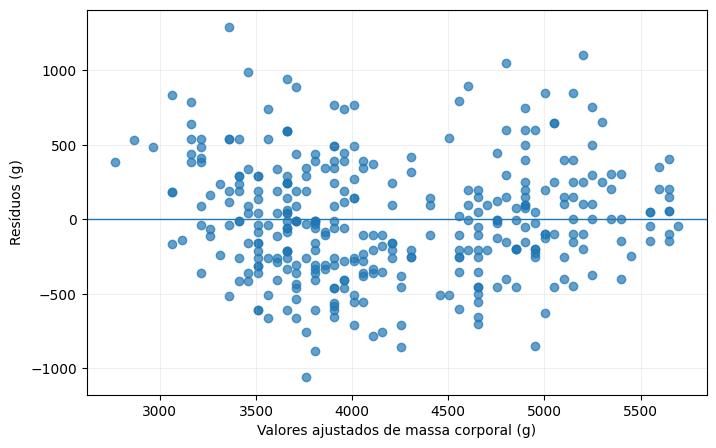

In [ ]:

plt.figure(figsize=(8, 5))
plt.scatter(dados["massa_ajustada_g"], dados["residuo_g"], alpha=0.7)
plt.axhline(0, linewidth=1)
plt.xlabel("Valores ajustados de massa corporal (g)")
plt.ylabel("Resíduos (g)")
plt.grid(alpha=0.2)
plt.show()



# 15. Histograma dos resíduos


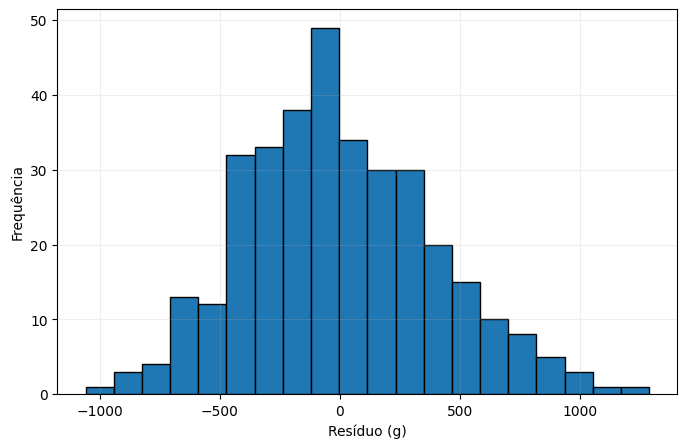

In [ ]:

plt.figure(figsize=(8, 5))
plt.hist(dados["residuo_g"], bins=20, edgecolor="black")
plt.xlabel("Resíduo (g)")
plt.ylabel("Frequência")
plt.grid(alpha=0.2)
plt.show()



# 16. Gráfico Q-Q dos resíduos

O gráfico Q-Q ajuda a avaliar se a distribuição dos resíduos é aproximadamente compatível com uma distribuição normal.


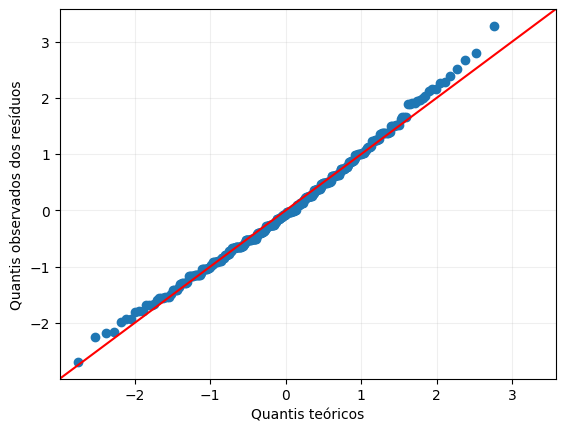

In [ ]:

sm.qqplot(dados["residuo_g"], line="45", fit=True)
plt.xlabel("Quantis teóricos")
plt.ylabel("Quantis observados dos resíduos")
plt.grid(alpha=0.2)
plt.show()



# 17. Previsão

Exemplo:

> Qual é a massa corporal média esperada para um pinguim com nadadeira de **210 mm**?

É importante diferenciar:

- **intervalo de confiança da média esperada**;
- **intervalo de previsão para uma nova observação**.


In [ ]:

novo_x = 210

novo = sm.add_constant(
    pd.DataFrame({"flipper_length_mm": [novo_x]}),
    has_constant="add"
)

previsao = modelo.get_prediction(novo).summary_frame(alpha=0.05)
previsao


,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,4653.138,25.394,4603.189,4703.086,3875.999,5430.276



### Resultado esperado da previsão

Para uma nadadeira de $210$ mm:

$
\hat{Y}\approx 4653\text{ g}
$

A previsão é uma consequência do modelo estatístico e **não deve ser interpretada como evidência causal**.

Também devemos evitar extrapolar para valores de $X$ muito fora do intervalo observado na amostra.



# 18. Erros comuns

1. **Calcular a correlação sem olhar o gráfico de dispersão.**
2. **Confundir correlação com causalidade.**
3. Interpretar apenas o valor-p e ignorar a magnitude de $r$.
4. Ignorar valores extremos.
5. Interpretar $R^2$ como uma medida absoluta de “qualidade”.
6. Extrapolar a reta para valores muito fora da região observada.
7. Concluir que não há associação entre variáveis apenas porque $r\approx0$, mesmo quando a relação pode ser não linear.
8. Ignorar grupos biológicos importantes, como espécies, sexo, local ou população.



# 19. Atividade de interpretação

Considere os resultados aproximados:

$
r=0{,}871
$

$
\widehat{\text{massa}}
=
-5780{,}83
+
49{,}69(\text{nadadeira})
$

$
R^2=0{,}759
$

Responda:

1. A relação é positiva ou negativa?
2. Como você interpreta $r=0{,}871$?
3. Como você interpreta o coeficiente $49{,}69$?
4. O que significa $R^2=0{,}759$?
5. Esses resultados provam que aumentar a nadadeira causa aumento da massa corporal?
6. Seria adequado utilizar o modelo para prever a massa de um pinguim com nadadeira de 400 mm?



## Gabarito

1. **Positiva.**
2. Existe uma associação linear positiva forte entre as duas variáveis.
3. Cada aumento de 1 mm no comprimento da nadadeira está associado a aproximadamente 49,7 g de aumento médio esperado na massa corporal.
4. Aproximadamente 75,9% da variabilidade da massa corporal é explicada pela relação linear com o comprimento da nadadeira no modelo considerado.
5. **Não.** Correlação e regressão observacional não estabelecem causalidade.
6. **Não.** Seria uma extrapolação muito além da faixa observada nos dados.



# 22. Síntese

### Correlação
Responde principalmente:

> Qual é a direção e a intensidade da associação linear entre $X$ e $Y$?

### Regressão linear simples
Responde principalmente:

> Como o valor médio esperado de $Y$ muda quando $X$ aumenta?

### Lembretes

- examine sempre o gráfico;
- interprete os coeficientes no contexto biológico;
- avalie os resíduos;
- não confunda associação com causalidade;
- evite extrapolações;
- considere variáveis de agrupamento e possíveis fatores de confusão.
